In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report    
)

from xgboost import XGBClassifier

In [2]:
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'

In [3]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns = data.feature_names)

df['target_original'] = data.target

df['target'] = 1 - df['target_original']

df['target_name'] = df['target'].map({
    0: 'benign',
    1: 'malignant'    
})

print('데이터 크기 (행, 열): ', df.shape)

데이터 크기 (행, 열):  (569, 33)


In [4]:
df[['target_original', 'target', 'target_name']].head()

,target_original,target,target_name
0,0,1,malignant
1,0,1,malignant
2,0,1,malignant
3,0,1,malignant
4,0,1,malignant


In [5]:
df['target_name'].value_counts()

target_name
benign       357
malignant    212
Name: count, dtype: int64

In [6]:
X = df.drop(columns = ['target_original', 'target', 'target_name'])
y = df['target']

print('X의 열 개수: ', X.shape[1])
print('정답 관련 컬럼이 X에 있나요?',
     any(col in X.columns for  col in ['target_original', 'target', 'target_name']))

X의 열 개수:  30
정답 관련 컬럼이 X에 있나요? False


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state=42,
    stratify = y,
    test_size = 0.2
)

print('학습용 데이터 개수: ', X_train.shape[0])
print('평가용 데이터 개수: ', X_test.shape[0])

학습용 데이터 개수:  455
평가용 데이터 개수:  114


In [8]:
model = XGBClassifier(
    random_state = 42,
    eval_metric = 'logloss',
    n_jobs = 1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred_proba = model.predict_proba(X_test)[:, 1]

print('예측 완료! 예측한 데이터 개수: ', len(y_pred))
print('예측값 예시 (앞 10개): ', y_pred[:10])
print('malignant 확률 예시 (앞 5개): ', y_pred_proba[:5].round(3))

예측 완료! 예측한 데이터 개수:  114
예측값 예시 (앞 10개):  [0 1 0 1 0 0 1 0 0 0]
malignant 확률 예시 (앞 5개):  [0.001 1.    0.04  0.993 0.017]


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print('accuracy: ', accuracy)
print(f'즉, 전체의 약 {accuracy * 100:.1f}%를 맞혔습니다.')

accuracy:  0.9736842105263158
즉, 전체의 약 97.4%를 맞혔습니다.


In [10]:
class_names = ['benign', 'malignant']

cm = confusion_matrix(
    y_test, y_pred,
    labels = [0, 1]
)

print(cm)

[[72  0]
 [ 3 39]]


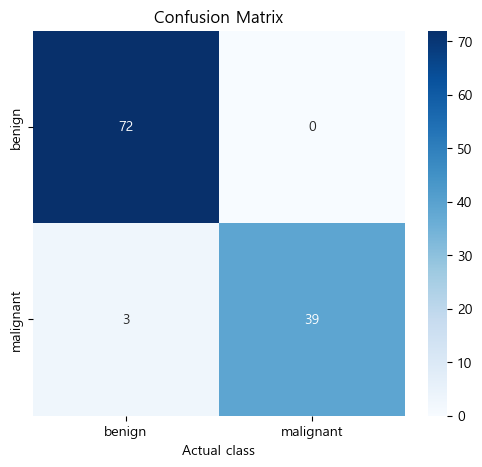

In [11]:
plt.figure(figsize = (6, 5))

sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = class_names,
    yticklabels = class_names
)

plt.xlabel('Predicted class')
plt.xlabel('Actual class')
plt.title('Confusion Matrix')
plt.show()

In [12]:
print(
    classification_report(
        y_test,
        y_pred,
        labels = [0, 1],
        target_names = class_names
    )
)

              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [13]:
X_test_reset = X_test.reset_index(drop = True).copy()

In [14]:
y_test_reset = y_test.reset_index(drop = True)

y_test_reset

0      0
1      1
2      0
3      1
4      0
      ..
109    0
110    0
111    0
112    1
113    1
Name: target, Length: 114, dtype: int64

In [15]:
result_df = X_test.copy()

result_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,12.82,15.97,83.74,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523
250,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,...,25.58,27.00,165.30,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849
375,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,...,16.97,19.14,113.10,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,16.33,30.86,109.50,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353
455,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,...,15.05,41.61,96.69,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,11.04,14.93,70.67,372.7,0.07987,0.07079,0.03546,0.02074,0.2003,0.06246,...,12.09,20.83,79.73,447.1,0.1095,0.1982,0.15530,0.06754,0.3202,0.07287
534,10.96,17.62,70.79,365.6,0.09687,0.09752,0.05263,0.02788,0.1619,0.06408,...,11.62,26.51,76.43,407.5,0.1428,0.2510,0.21230,0.09861,0.2289,0.08278
448,14.53,19.34,94.25,659.7,0.08388,0.07800,0.08817,0.02925,0.1473,0.05746,...,16.30,28.39,108.10,830.5,0.1089,0.2649,0.37790,0.09594,0.2471,0.07463
205,15.12,16.68,98.78,716.6,0.08876,0.09588,0.07550,0.04079,0.1594,0.05986,...,17.77,20.24,117.70,989.5,0.1491,0.3331,0.33270,0.12520,0.3415,0.09740


In [16]:
result_df['y_true'] = y_test_reset.values

result_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,y_true
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,15.97,83.74,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523,0
250,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,...,27.00,165.30,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849,1
375,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,...,19.14,113.10,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960,0
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,30.86,109.50,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353,1
455,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,...,41.61,96.69,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,11.04,14.93,70.67,372.7,0.07987,0.07079,0.03546,0.02074,0.2003,0.06246,...,20.83,79.73,447.1,0.1095,0.1982,0.15530,0.06754,0.3202,0.07287,0
534,10.96,17.62,70.79,365.6,0.09687,0.09752,0.05263,0.02788,0.1619,0.06408,...,26.51,76.43,407.5,0.1428,0.2510,0.21230,0.09861,0.2289,0.08278,0
448,14.53,19.34,94.25,659.7,0.08388,0.07800,0.08817,0.02925,0.1473,0.05746,...,28.39,108.10,830.5,0.1089,0.2649,0.37790,0.09594,0.2471,0.07463,0
205,15.12,16.68,98.78,716.6,0.08876,0.09588,0.07550,0.04079,0.1594,0.05986,...,20.24,117.70,989.5,0.1491,0.3331,0.33270,0.12520,0.3415,0.09740,1


In [17]:
result_df['y_pred'] = y_pred

result_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,y_true,y_pred
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,83.74,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523,0,0
250,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,...,165.30,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849,1,1
375,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,...,113.10,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960,0,0
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,109.50,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353,1,1
455,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,...,96.69,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,11.04,14.93,70.67,372.7,0.07987,0.07079,0.03546,0.02074,0.2003,0.06246,...,79.73,447.1,0.1095,0.1982,0.15530,0.06754,0.3202,0.07287,0,0
534,10.96,17.62,70.79,365.6,0.09687,0.09752,0.05263,0.02788,0.1619,0.06408,...,76.43,407.5,0.1428,0.2510,0.21230,0.09861,0.2289,0.08278,0,0
448,14.53,19.34,94.25,659.7,0.08388,0.07800,0.08817,0.02925,0.1473,0.05746,...,108.10,830.5,0.1089,0.2649,0.37790,0.09594,0.2471,0.07463,0,0
205,15.12,16.68,98.78,716.6,0.08876,0.09588,0.07550,0.04079,0.1594,0.05986,...,117.70,989.5,0.1491,0.3331,0.33270,0.12520,0.3415,0.09740,1,0


In [18]:
result_df['y_true_name'] = result_df['y_true'].map({0:'benign', 1:'malignant'})

result_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,y_true,y_pred,y_true_name
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523,0,0,benign
250,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,...,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849,1,1,malignant
375,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,...,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960,0,0,benign
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353,1,1,malignant
455,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,...,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675,0,0,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,11.04,14.93,70.67,372.7,0.07987,0.07079,0.03546,0.02074,0.2003,0.06246,...,447.1,0.1095,0.1982,0.15530,0.06754,0.3202,0.07287,0,0,benign
534,10.96,17.62,70.79,365.6,0.09687,0.09752,0.05263,0.02788,0.1619,0.06408,...,407.5,0.1428,0.2510,0.21230,0.09861,0.2289,0.08278,0,0,benign
448,14.53,19.34,94.25,659.7,0.08388,0.07800,0.08817,0.02925,0.1473,0.05746,...,830.5,0.1089,0.2649,0.37790,0.09594,0.2471,0.07463,0,0,benign
205,15.12,16.68,98.78,716.6,0.08876,0.09588,0.07550,0.04079,0.1594,0.05986,...,989.5,0.1491,0.3331,0.33270,0.12520,0.3415,0.09740,1,0,malignant


In [19]:
result_df['y_pred_name'] = result_df['y_pred'].map({0:'benign', 1:'malignant'})

result_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,y_true,y_pred,y_true_name,y_pred_name
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523,0,0,benign,benign
250,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,...,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849,1,1,malignant,malignant
375,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,...,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960,0,0,benign,benign
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353,1,1,malignant,malignant
455,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,...,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675,0,0,benign,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,11.04,14.93,70.67,372.7,0.07987,0.07079,0.03546,0.02074,0.2003,0.06246,...,0.1095,0.1982,0.15530,0.06754,0.3202,0.07287,0,0,benign,benign
534,10.96,17.62,70.79,365.6,0.09687,0.09752,0.05263,0.02788,0.1619,0.06408,...,0.1428,0.2510,0.21230,0.09861,0.2289,0.08278,0,0,benign,benign
448,14.53,19.34,94.25,659.7,0.08388,0.07800,0.08817,0.02925,0.1473,0.05746,...,0.1089,0.2649,0.37790,0.09594,0.2471,0.07463,0,0,benign,benign
205,15.12,16.68,98.78,716.6,0.08876,0.09588,0.07550,0.04079,0.1594,0.05986,...,0.1491,0.3331,0.33270,0.12520,0.3415,0.09740,1,0,malignant,benign


In [20]:
result_df['is_correct'] = result_df['y_true'] == result_df['y_pred']

In [21]:
wrong_df = result_df [ result_df['is_correct'] == False ]

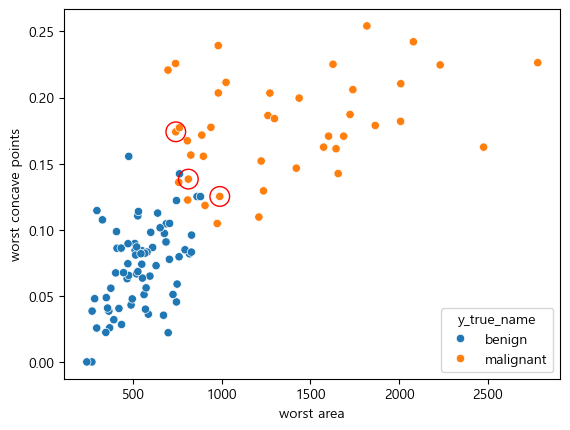

In [22]:
sns.scatterplot(
                data = result_df,
                x = 'worst area',
                y='worst concave points',
                hue = 'y_true_name'                
                )

plt.scatter(
            x = wrong_df['worst area'],
            y = wrong_df['worst concave points'],
            s = 200,
            edgecolors = 'red',
            facecolors = 'none'
            )

In [40]:
scaler_exam_df = pd.DataFrame({
                    'house_price'       :[120000, 115000, 10000,  110000, 119000],
                    'owner_age'         :[24,     38,     65,     42,     52],
                    'is_sale_next_month':[0,      1,      0,      1,      1]
})

scaler_exam_df

,house_price,owner_age,is_sale_next_month
0,120000,24,0
1,115000,38,1
2,10000,65,0
3,110000,42,1
4,119000,52,1


In [41]:
scaler_exam_df[['house_price', 'owner_age']].mean()

house_price    94800.0
owner_age         44.2
dtype: float64

In [42]:
scaler_exam_df[['house_price', 'owner_age']].std()

house_price    47567.846283
owner_age         15.368800
dtype: float64

In [43]:
( scaler_exam_df[['house_price', 'owner_age']] - scaler_exam_df[['house_price', 'owner_age']].mean() )\
    / scaler_exam_df[['house_price', 'owner_age']].std()

,house_price,owner_age
0,0.529770,-1.314351
1,0.424657,-0.403415
2,-1.782717,1.353391
3,0.319544,-0.143147
4,0.508747,0.507522


In [44]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

scaler_exam_df[['house_price', 'owner_age']]

,house_price,owner_age
0,120000,24
1,115000,38
2,10000,65
3,110000,42
4,119000,52


In [46]:
scaler.fit(scaler_exam_df[['house_price', 'owner_age']])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [48]:
scaler.transform(scaler_exam_df[['house_price', 'owner_age']])

array([[ 0.59230044, -1.4694893 ],
       [ 0.47478052, -0.45103137],
       [-1.99313801,  1.5131375 ],
       [ 0.35726059, -0.16004339],
       [ 0.56879646,  0.56742656]])

In [56]:
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)

In [57]:
scaler.transform(X_test)

array([[-0.77089916, -2.00602473, -0.76451652, ..., -0.38805702,
         0.16254727,  0.06095804],
       [ 1.89472636,  0.96648861,  1.89081582, ...,  1.42292627,
         0.33722232, -0.31041892],
       [ 0.56051506, -0.78108791,  0.57044007, ...,  0.14391558,
         0.38009711,  0.30174696],
       ...,
       [ 0.10179251, -0.01812727,  0.08238707, ..., -0.29280517,
        -0.70288824, -0.52310661],
       [ 0.26682074, -0.63876192,  0.26586259, ...,  0.14541325,
         0.79614133,  0.73153038],
       [ 0.53254417,  0.05420233,  0.48133495, ...,  0.54678897,
        -0.41864428, -1.11598733]], shape=(114, 30))

In [58]:
X_train_scaler.shape

(455, 30)

In [59]:
from sklearn.decomposition import PCA

In [66]:
pca = PCA(n_components = 2)
X_train_pca = pca.fit_transform(X_train_scaler)
X_test_pca = pca.transform(X_train_scaler)

print(X_train_pca, X_test_pca)

[[-8.75937458e-01 -2.57130887e+00]
 [-2.50512803e+00  1.92452607e-01]
 [-1.35411680e+00  4.17850942e-01]
 [ 4.85409144e+00  3.01757631e+00]
 [ 2.92622452e+00 -1.86654594e+00]
 [ 1.17596996e+01 -7.57381151e+00]
 [-2.16133856e+00  5.68874521e-01]
 [ 1.24063857e+00  9.63396648e-01]
 [-1.00949036e+00 -1.60570865e+00]
 [ 2.48457559e+00 -3.89112344e+00]
 [ 2.04013095e+00  3.11158973e-01]
 [ 9.19934481e+00 -5.61605803e+00]
 [-2.65050527e+00  1.52509969e+00]
 [ 5.21715943e+00 -1.12978557e-01]
 [-3.02812325e+00 -5.63518810e-01]
 [-1.61256682e+00 -1.55366586e+00]
 [-1.40016136e+00  1.45612103e+00]
 [-6.76258877e-01  1.74530793e+00]
 [-3.42972911e+00 -3.87796425e-01]
 [-4.85918556e+00 -2.23108672e+00]
 [-3.50388061e+00 -5.75829885e-01]
 [-8.84852131e-01  1.67227754e-01]
 [ 3.16687021e+00 -9.74202914e-01]
 [ 1.38964992e+00  7.68427212e+00]
 [ 1.57062285e+01 -7.76262862e+00]
 [-1.71301114e+00  1.03963520e+00]
 [ 9.45511767e-01  1.04216950e+00]
 [-3.33432939e+00  7.96684979e-01]
 [ 4.72518624e+00 -4

In [68]:
from sklearn.metrics import confusion_matrix, classification_report

threshold_list = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01, 0.001]

In [69]:
y_pred_proba

array([1.13609107e-03, 9.99782741e-01, 3.99268866e-02, 9.93436217e-01,
       1.69566628e-02, 1.00996264e-03, 8.67667556e-01, 9.96995135e-04,
       9.41021790e-05, 1.81898227e-04, 9.81809974e-01, 1.55503990e-03,
       9.99786794e-01, 5.24819421e-04, 2.20141985e-04, 1.16337265e-04,
       2.65839673e-03, 3.51775787e-04, 1.02739390e-02, 6.46480534e-04,
       2.64419429e-03, 5.92395663e-04, 9.99816835e-01, 9.99395609e-01,
       5.56348681e-01, 1.64135359e-04, 8.20630870e-04, 9.21686172e-01,
       9.99478281e-01, 9.99539733e-01, 9.99568284e-01, 7.11447268e-04,
       9.99835610e-01, 9.99239326e-01, 3.98001139e-04, 1.77244016e-04,
       9.41150138e-05, 6.63086903e-05, 9.82604444e-01, 2.05296301e-03,
       4.27948032e-03, 8.50411307e-04, 6.36209905e-01, 2.16234243e-03,
       1.81187484e-02, 9.99601662e-01, 7.48542976e-03, 9.99061644e-01,
       3.58641800e-03, 3.75042058e-04, 9.98892844e-01, 9.99558270e-01,
       3.23750864e-04, 4.45929589e-03, 1.89055965e-04, 9.06293452e-01,
      

In [83]:
for threshold in threshold_list:
    print('=' * 30)
    print(f'threshold = {threshold}')
    print('=' * 30)
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    print(f'y_pred_threshold = {y_pred_threshold[:20]}')

    cm_threshold = confusion_matrix(y_test, y_pred_threshold, labels = [0, 1])
    print(f'cm_threshold = \n{cm_threshold}')
    print('\nClassification Report')
    print(
        classification_report(y_test, y_pred_threshold, labels = [0, 1], target_names = ['benign', 'malignant'])
    )
    
    print('=' * 30)

threshold = 0.5
y_pred_threshold = [0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]
cm_threshold = 
[[72  0]
 [ 3 39]]

Classification Report
              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

threshold = 0.4
y_pred_threshold = [0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]
cm_threshold = 
[[72  0]
 [ 3 39]]

Classification Report
              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

threshold = 0.3
y_pred_threshold = [0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]